In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pathlib import Path
import spacy as sp

In [2]:
input_path=Path().resolve()/'input'

# Loading Dataa

In [3]:
testing_data=pl.read_csv(input_path/'Corona_NLP_test.csv')

In [4]:
training_data=pl.read_csv(input_path/'Corona_NLP_train.csv')

# Data Preprocessing

### Data Preprocessing pipeline:
1. clean missing values - Done
2. fix data types -Done
3. Text Cleaning -Done
4. tokenize the text of the target column -Done
5. remove stop words Done
6. Stemming words (Porter Stemmer) -Done

Note: Lemmatization is a very costly operation that takes minutes sometimes hours which is not suitable entirely for this project

In [5]:
testing_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,834,0,0,0


In [6]:
# checking nulls
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,8590,0,0,0


null exists at location

We will impute those nulls with unknown value

In [7]:
training_data=training_data.with_columns(pl.col('Location').fill_null('unknown'))
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [8]:
testing_data=testing_data.with_columns(pl.col('Location').fill_null('unknown'))
testing_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [9]:
# Converting the tweetat to polars datetime
training_data=training_data.with_columns(pl.col('TweetAt').str.to_date())
testing_data=testing_data.with_columns(pl.col('TweetAt').str.to_date())

#### clean data and tokenize

In [10]:
from lib import TextClassification
preprocessor=TextClassification(training_data)

In [11]:
# Very Fast method --polars nativen method
training_data=training_data.pipe(preprocessor.preprocess_pl_native)
testing_data=testing_data.pipe(preprocessor.preprocess_pl_native)

#### Removing stop words and punc

In [12]:
training_data=training_data.with_columns(
    pl.col('OriginalTweet').str.split(' ').map_elements(
        lambda x: preprocessor.remove_stop_words_and_punc(x), return_dtype=pl.String))
testing_data=testing_data.with_columns(
    pl.col('OriginalTweet').str.split(' ').map_elements(
        lambda x: preprocessor.remove_stop_words_and_punc(x), return_dtype=pl.String))

### Stemming

In [ ]:
# Stemming words using porter stemming
training_data=training_data.with_columns(
    pl.col('OriginalTweet').map_elements(
        lambda x: preprocessor.porter_stem(x), return_dtype=pl.String))

testing_data=testing_data.with_columns(
    pl.col('OriginalTweet').map_elements(
        lambda x: preprocessor.porter_stem(x), return_dtype=pl.String))

### Or For more accuracy use lemmatization rather than stemming --takes time (e.g., 5 min)

In [ ]:
training_data=training_data.with_columns(
    pl.col('OriginalTweet').map_elements(
        lambda x: preprocessor.lemmatize_spacy(x), return_dtype=pl.String))

testing_data=testing_data.with_columns(
    pl.col('OriginalTweet').map_elements(
        lambda x: preprocessor.lemmatize_spacy(x), return_dtype=pl.String))

### Or Use Spacy Pipeline --- takes time and result is so bad

In [ ]:
# # Method one using spacy cleaner --> very slow
# training_data=training_data.with_columns(pl.col('OriginalTweet').map_elements(lambda x: preprocessor.preprocess_spacy(x), return_dtype=pl.String))
# testing_data=testing_data.with_columns(pl.col('OriginalTweet').map_elements(lambda x: preprocessor.preprocess_spacy(x), return_dtype=pl.String))

# Data Exploration

### Data Exploration Steps:
1. get insights from the data
2. printing statistics
3. Checking missing values and duplicates
4. checking categorical distribution
5. Printing some plots (Barplot, Pie chart)
6. Word Cloud Plot
7. Word Cloud For each sentiment
8. Word counter for each sentiment
9. Text Length for each Sentiment

In [ ]:
training_data.head(10)

In [ ]:
training_data.describe()

### Checking duplicates


In [ ]:
is_dup=training_data.is_duplicated()
training_data.filter(is_dup)

There are no duplicates within the data

There are many null values in the location field <br>
Date format for the TweetAt is not accurate needs to be changed

In [ ]:
## understanding screen name
training_data.select(pl.col('ScreenName')).unique().count()

In [ ]:
# All values are unique so its an identity to the test

In [ ]:
# describing the categorical variables
training_data.to_pandas().describe(include="object")

- Most common location is Londan 
- Most common tweet date is 3448
- Most common Sentiment is Positive

In [ ]:
# Visualizing the sentiment column`

In [ ]:
from lib import TextClassification
sentiment_data=training_data.group_by('Sentiment').len().select(pl.col('Sentiment'), pl.col('len').alias('Counts'))

In [ ]:
Plots=TextClassification(sentiment_data)
Plots.barplot_seaborn('Sentiment','Counts')

In [ ]:
Plots.pie('Counts','Sentiment')

In [ ]:
# Correlation between Sentiment and Original Tweet
data_corr=training_data.select(pl.corr('OriginalTweet','Sentiment',method="spearman"))
data_corr

### Word cloud plot

In [ ]:
Plots=TextClassification(training_data)
Plots.WorldCloud()

### Word cloud for Neutral Sentiment

In [ ]:
Plots.WorldCloud('Neutral')

### Word cloud for Extermely Negative Sentiment

In [ ]:
Plots.WorldCloud('Extremely Negative')

### Word cloud for Negative Sentiment

In [ ]:
Plots.WorldCloud('Negative')

### Word cloud for Positive Sentiment

In [ ]:
Plots.WorldCloud('Positive')

### Word cloud for Exteremly Positive Sentiment

In [ ]:
Plots.WorldCloud('Extremely Positive')

_______________________

### Top Words Count for Neutral Sentiment

In [ ]:
Plots.Top_words('Neutral')

### Top Words Count for Extermely Negative Sentiment

In [ ]:
Plots.Top_words('Extremely Negative')

### Top Words Count for Negative Sentiment

In [ ]:
Plots.Top_words('Negative')

### Top Words Count for Positive Sentiment

In [ ]:
Plots.Top_words('Positive')

### Top Words Count for Exteremly Positive Sentiment

In [ ]:
Plots.Top_words('Extremely Positive')

### Boxplots for the Text Length for each Sentiment

In [ ]:
Plots.boxplot()

# Modelling

### Modelling Pipeline:
1. Apply TFIDF vectorizer to the training and testing data
2. Run the three selected models (Logistic Regression, Naive Bayes, Random Forest)
3. Create a function to evaluate those models with visualization
4. compare the performance of those models.
5. Perform Hyperparameter tuning -> a function applied to all three models
6. Compare model's performance before and after tuning with visualization
7. Selection of the best Model based on the evaluation metrics. 

note: there will be no test split as the data is already splitted in two different files

In [ ]:
from lib import TextClassification
modelling=TextClassification(training_data)

### Manual tf IDF

In [ ]:
modelling.tf_idf(training_data, testing_data)

### Prepare the data and Encode classification categories

In [ ]:
modelling.prepare_data(training_data, testing_data)

### Models

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(max_iter=1000, class_weight='balanced', C=20)
y_test, y_predict, class_names=modelling.modelling(lg, training_data, testing_data)

In [ ]:
modelling.display_confusion_mx(y_test, y_predict, class_names)

### Naive Bayes

In [18]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB(alpha=0.01)
y_test, y_predict, class_names=modelling.modelling(nb, training_data, testing_data)

                    precision    recall  f1-score   support

Extremely Negative       0.54      0.30      0.39       592
Extremely Positive       0.64      0.31      0.41       599
          Negative       0.41      0.48      0.45      1041
           Neutral       0.59      0.45      0.51       619
          Positive       0.39      0.61      0.47       947

          accuracy                           0.45      3798
         macro avg       0.52      0.43      0.45      3798
      weighted avg       0.49      0.45      0.45      3798



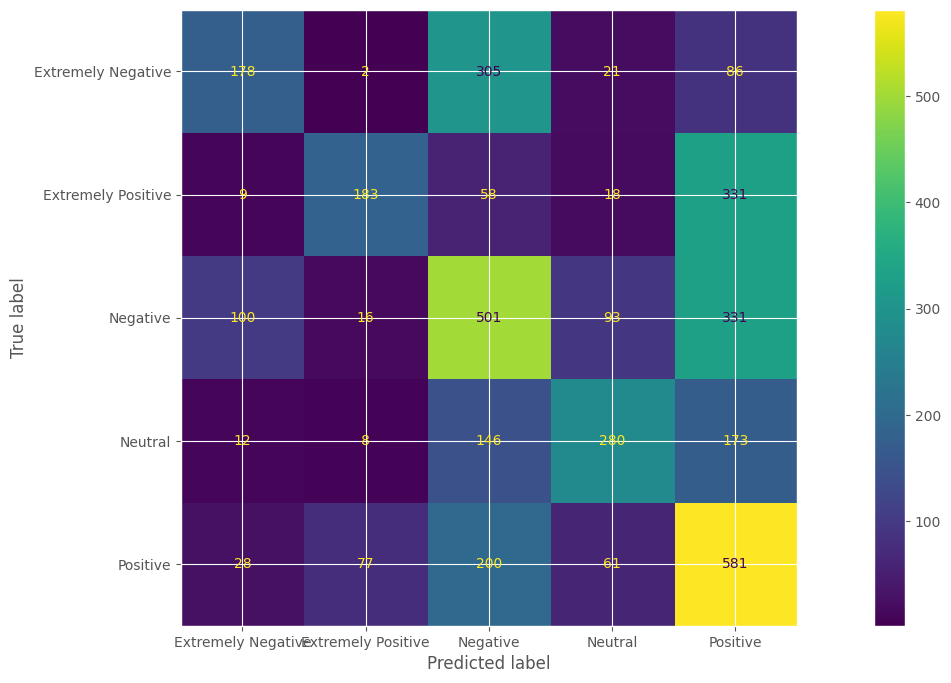

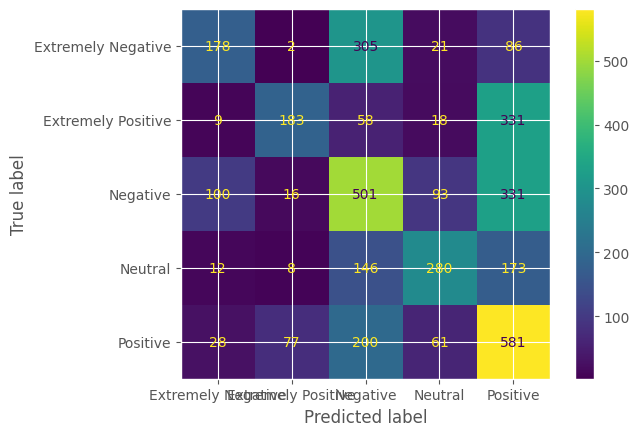

In [19]:
modelling.display_confusion_mx(y_test, y_predict, class_names)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
y_test, y_predict, class_names=modelling.modelling(rf, training_data, testing_data)

In [ ]:
modelling.display_confusion_mx(y_test, y_predict, class_names)

### Model Tuning --must compare the results before and after tuning

The results before tuning are given above

### Logistic regression tuning

In [ ]:
import pandas as pd
lr_param_grid = {
    'penalty': ['l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000,2000],
    'class_weight': [None, 'balanced']
}
lg=LogisticRegression()
best_param, best_score=modelling.tunning(training_data, testing_data, lg, lr_param_grid)

### Run and test model

In [ ]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(best_param)
y_test, y_predict, class_names=modelling.modelling(lg, training_data, testing_data)

In [ ]:
modelling.display_confusion_mx(y_test, y_predict, class_names)

### Random Forest tuning

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'classifier__class_weight': [None, 'balanced']
}
rf=RandomForestClassifier()

best_param, best_score=modelling.tunning(training_data, testing_data, rf, rf_param_grid)

### Run and test model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(best_param)
y_test, y_predict, class_names=modelling.modelling(rf, training_data, testing_data)

In [ ]:
modelling.display_confusion_mx(y_test, y_predict, class_names)

### Naive Bayes Tuning

In [20]:
nb_param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'force_alpha':[True, False],
    'fit_prior': [True, False]
}
nb=MultinomialNB()

best_param, best_score=modelling.tunning(training_data, testing_data, nb, nb_param_grid)

In [21]:
best_param, best_score

({'alpha': 1, 'fit_prior': False, 'force_alpha': True}, 0.4693975086997132)

### Run and test model

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB(**best_param)
y_test, y_predict, class_names=modelling.modelling(nb, training_data, testing_data)

In [ ]:
modelling.display_confusion_mx(y_test, y_predict, class_names)